# Bank Transaction Analytics and Anomaly Detection Using Machine Learning

---
### Student Name

**Dharshini**

---

### Bach PGA 38

**Data Science With Gen AI**

---

# Executive Summary

This project presents a comprehensive analysis of bank transaction data using machine learning techniques to identify unusual transaction patterns. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, feature selection, data scaling, and anomaly detection using the Isolation Forest algorithm.

The project aims to help financial institutions monitor transaction behavior, identify potentially suspicious transactions, and generate actionable business insights. The developed workflow demonstrates how machine learning can support financial monitoring and improve decision-making in banking systems.

---
  
# Project Workflow

```


                 Bank Transaction Dataset
                          │
                          ▼
                 Data Understanding
                          │
                          ▼
              Data Cleaning & Preprocessing
                          │
                          ▼
             Exploratory Data Analysis (EDA)
                          │
                          ▼
                 Feature Engineering
                          │
                          ▼
             Feature Selection & Scaling
                          │
                          ▼
              Isolation Forest Algorithm
                          │
                          ▼
                 Anomaly Detection
                          │
                          ▼
               Model Evaluation
                          │
                          ▼
                 Business Insights
                          │
                          ▼
                   Final Conclusion
```



#  Table of Contents

- [1. Introduction](#1.-Introduction)
- [2. Problem Statement](#2.-Problem-Statement)
- [3. Objectives](#3.-Objectives)
- [4. Dataset Description](#4.-Dataset-Description)
- [5. Import Libraries](#5.-Import-Libraries)
- [6. Load Dataset](#6.-Load-Dataset)
- [7. Data Understanding](#7.-Data-Understanding)
- [8. Data Cleaning & Preprocessing](#8.-Data-Cleaning-&-Preprocessing)
- [9. Exploratory Data Analysis (EDA)](#9.-Exploratory-Data-Analysis-(EDA))
- [10. Feature Engineering](#10.-Feature-Engineering)
- [11. Feature Selection](#11.-Feature-Selection)
- [12. Data Scaling](#12.-Data-Scaling)
- [13. Anomaly Detection using Isolation Forest](#13.-Anomaly-Detection-using-Isolation-Forest)
- [14. Model Evaluation](#14.-Model-Evaluation)
- [15. Business Insights](#15.-Business-Insights)
- [16. Conclusion](#16.-Conclusion)
- [17. Future Scope](#17.-Future-Scope)
- [18. References](#18.-References)

# 1. Introduction

The banking industry processes millions of financial transactions every day. Monitoring and analyzing these transactions is essential for understanding customer behavior, identifying unusual activities, and ensuring financial security.

Machine Learning provides efficient techniques for analyzing large volumes of transaction data. By applying data preprocessing, exploratory data analysis (EDA), feature engineering, and anomaly detection algorithms, banks can identify suspicious transaction patterns and support informed financial decision-making.

This project focuses on analyzing bank transaction records and detecting anomalous transactions using Machine Learning.

# 2. Problem Statement

Banks handle thousands of financial transactions daily, making manual monitoring difficult and time-consuming.

The objective of this project is to analyze bank transaction records, identify unusual transaction patterns using Machine Learning techniques, and generate meaningful business insights that support effective financial monitoring and decision-making.

# 3. Objectives

- Analyze bank transaction records.
- Clean and preprocess the dataset.
- Perform Exploratory Data Analysis (EDA).
- Engineer meaningful features.
- Detect anomalous transactions using Machine Learning.
- Evaluate anomaly detection performance.
- Generate actionable business insights.

# 4. Dataset Description

The dataset contains bank account transaction records extracted from an account statement.

## Dataset Features

| Feature | Description |
|---------|-------------|
| Transaction Date | Date of the transaction |
| Description | Transaction narration |
| Withdrawal Amount | Debit amount |
| Deposit Amount | Credit amount |
| Balance | Available account balance |
| Reference Number | Unique transaction reference number |

The dataset includes both debit and credit transactions and is used to analyze transaction behavior and detect anomalous transactions using Machine Learning techniques.

# 5. Import Libraries

In this section, the required Python libraries are imported for data manipulation, visualization, preprocessing, and machine learning. These libraries provide the tools needed to analyze bank transaction data and detect anomalous transactions.

In [1]:
!pip install openpyxl

In [2]:
import openpyxl
print("openpyxl installed successfully")

openpyxl installed successfully


In [3]:

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning - Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Clustering 
from sklearn.cluster import DBSCAN, KMeans

# Model Evaluation
from sklearn.metrics import silhouette_score

# Save Model
import joblib

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# 6. Load Dataset

The dataset is loaded into a Pandas DataFrame for further analysis. This step ensures that the transaction records are available for preprocessing, visualization, and machine learning.

In [4]:
df = pd.read_excel(r'C:\Users\dell\OneDrive\Desktop\Bank_Transaction_Analytics\Dataset\Original_Bank_Statement.xlsx')

In [5]:
df.head()

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance
0,-,-,Opening Balance,-,-,-,"-13,75,768.75"
1,1,01 Apr 2024,MB:v91 payment,000388119179,"3,00,000.00",NaN,"16,75,768.75"
2,2,01 Apr 2024,Recd:IMPS/409209339954/ONE97COMMU/KKB\nK/X0961...,IMPS-409209469333,NaN,"7,420.00","16,68,348.75"
3,3,01 Apr 2024,KotakPayout-079058004630063-010424,NaN,NaN,"85,433.76","15,82,914.99"
4,4,01 Apr 2024,MB:vinayaga bills payments,000388166922,"69,526.00",NaN,"16,52,440.99"


In [6]:
df.tail()

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance
3737,1888,31 Mar 2026,NEFT AXISCN1297594863 PAYU PAYMENTS PVT\nLTD U...,NEFTINW-1539115620,NaN,"30,080.00","7,95,878.32"
3738,1889,31 Mar 2026,NEFT AXISCN1297919912 WORLDLINE\nEPAYMENTS IND...,NEFTINW-1539420820,NaN,"47,541.97","8,43,420.29"
3739,1890,31 Mar 2026,SentIMPS609010270611Gopinathan/ESFBX201\n0/KKB...,IMPS-609010527882,"35,000.00",NaN,"8,08,420.29"
3740,1891,31 Mar 2026,SentIMPS609011311749tsp super\n/ESFBX9340/KKBK...,IMPS-609011591666,"15,000.00",NaN,"7,93,420.29"
3741,1892,31 Mar 2026,SentIMPS609019699969tsp super\n/ESFBX9340/KKBK...,IMPS-609019221243,"42,500.00",NaN,"7,50,920.29"


In [7]:
df.sample(5, random_state=42)

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance
3450,1601,2026-02-04 00:00:00,MB:stryder bno 8319257756,000511110855,166955.25,NaN,716453.58
1114,1114,08 Nov 2024,NEFT YESAP43130426440 ONE 97\nCOMMUNICATIONS L...,NEFTINW-1026834807,NaN,"1,210.00","10,16,915.90"
351,351,17 Jun 2024,MB:RECEIVED FROM K GOPINATHAN/CHIT\nAMOUNT,MB-998668832833,NaN,"1,50,000.00","4,35,016.29"
1983,134,2025-04-23 00:00:00,MB:reliance bno A61B1100002328,000458700577,97762,NaN,1274710.05
2321,472,22 Jun 2025,NEFT AXISCN0998796320 WORLDLINE INDIA\nPRIVATE...,NEFTINW-1249278143,NaN,"29,250.21","30,05,659.80"


# 7. Data Understanding

Before preprocessing the dataset, it is important to understand its structure, dimensions, data types, missing values, and duplicate records. This helps identify data quality issues and prepares the dataset for analysis.

In [8]:
# Dataset Shape
df.shape

(3742, 7)

In [9]:
# Column Names
df.columns

Index(['#', 'Date', 'Description', 'Chq/Ref. No.', 'Withdrawal (Dr.)',
       'Deposit (Cr.)', 'Balance'],
      dtype='str')

In [10]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3742 entries, 0 to 3741
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   #                 3742 non-null   object
 1   Date              3742 non-null   object
 2   Description       3742 non-null   str   
 3   Chq/Ref. No.      3543 non-null   str   
 4   Withdrawal (Dr.)  1353 non-null   object
 5   Deposit (Cr.)     2391 non-null   object
 6   Balance           3742 non-null   object
dtypes: object(5), str(2)
memory usage: 204.8+ KB


In [11]:
# Statistical Summary
df.describe(include="all")

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance
count,3742,3742,3742,3543,1353,2391,3742.00
unique,2622,765,3485,3532,593,2192,3707.00
top,-,01 Aug 2024,MB:SENT TO PROFICIENT\nTECHNOLOGIES/PROFICIENT...,IB,"1,00,000.00",1.00,2088344.21
freq,2,16,75,4,98,9,4.00


In [12]:
# Missing Values
df.isnull().sum()

#                      0
Date                   0
Description            0
Chq/Ref. No.         199
Withdrawal (Dr.)    2389
Deposit (Cr.)       1351
Balance                0
dtype: int64

In [13]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [14]:
# Data Types
df.dtypes

#                   object
Date                object
Description            str
Chq/Ref. No.           str
Withdrawal (Dr.)    object
Deposit (Cr.)       object
Balance             object
dtype: object

# 8. Data Cleaning & Preprocessing

Data preprocessing is an essential step in any machine learning project. It improves data quality by handling missing values, removing duplicate records, correcting data types, and creating useful features for analysis.

In [15]:
# Check Missing Values
df.isnull().sum()

#                      0
Date                   0
Description            0
Chq/Ref. No.         199
Withdrawal (Dr.)    2389
Deposit (Cr.)       1351
Balance                0
dtype: int64

In [16]:
# Remove Opening Balance Rows
df = df[df["Description"] != "Opening Balance"].copy()

In [17]:
# Reset Index
df.reset_index(drop=True, inplace=True)
df.head()

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance
0,1,01 Apr 2024,MB:v91 payment,000388119179,"3,00,000.00",NaN,"16,75,768.75"
1,2,01 Apr 2024,Recd:IMPS/409209339954/ONE97COMMU/KKB\nK/X0961...,IMPS-409209469333,NaN,"7,420.00","16,68,348.75"
2,3,01 Apr 2024,KotakPayout-079058004630063-010424,NaN,NaN,"85,433.76","15,82,914.99"
3,4,01 Apr 2024,MB:vinayaga bills payments,000388166922,"69,526.00",NaN,"16,52,440.99"
4,5,01 Apr 2024,Int.Coll:9500000306:02-03-2024 to 01-04-2024,NaN,"15,141.00",NaN,"16,67,581.99"


In [18]:
# Convert Date Column
df["Date"] = pd.to_datetime(df["Date"],format="%d %b %Y")

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3740 entries, 0 to 3739
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   #                 3740 non-null   object        
 1   Date              3740 non-null   datetime64[us]
 2   Description       3740 non-null   str           
 3   Chq/Ref. No.      3541 non-null   str           
 4   Withdrawal (Dr.)  1351 non-null   object        
 5   Deposit (Cr.)     2389 non-null   object        
 6   Balance           3740 non-null   object        
dtypes: datetime64[us](1), object(4), str(2)
memory usage: 204.7+ KB


In [20]:
# Currency Columns
money_cols = ["Withdrawal (Dr.)","Deposit (Cr.)","Balance"]
for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

In [21]:
df[money_cols].head()

,Withdrawal (Dr.),Deposit (Cr.),Balance
0,300000.0,NaN,1675768.75
1,NaN,7420.00,1668348.75
2,NaN,85433.76,1582914.99
3,69526.0,NaN,1652440.99
4,15141.0,NaN,1667581.99


In [22]:
df[money_cols] = df[money_cols].fillna(0)

In [23]:
df["Transaction Amount"] = (df["Withdrawal (Dr.)"] +df["Deposit (Cr.)"])

In [24]:
df["Transaction Type"] = np.where(df["Withdrawal (Dr.)"] > 0,"Debit","Credit")

In [25]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3740 entries, 0 to 3739
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   #                   3740 non-null   object        
 1   Date                3740 non-null   datetime64[us]
 2   Description         3740 non-null   str           
 3   Chq/Ref. No.        3541 non-null   str           
 4   Withdrawal (Dr.)    3740 non-null   float64       
 5   Deposit (Cr.)       3740 non-null   float64       
 6   Balance             3740 non-null   float64       
 7   Transaction Amount  3740 non-null   float64       
 8   Transaction Type    3740 non-null   str           
 9   Year                3740 non-null   int32         
 10  Month               3740 non-null   int32         
 11  Day                 3740 non-null   int32         
 12  Weekday             3740 non-null   str           
dtypes: datetime64[us](1), float64(4), int32(3), object(1), str(

In [27]:
df.head()

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance,Transaction Amount,Transaction Type,Year,Month,Day,Weekday
0,1,2024-04-01,MB:v91 payment,000388119179,300000.0,0.00,1675768.75,300000.00,Debit,2024,4,1,Monday
1,2,2024-04-01,Recd:IMPS/409209339954/ONE97COMMU/KKB\nK/X0961...,IMPS-409209469333,0.0,7420.00,1668348.75,7420.00,Credit,2024,4,1,Monday
2,3,2024-04-01,KotakPayout-079058004630063-010424,NaN,0.0,85433.76,1582914.99,85433.76,Credit,2024,4,1,Monday
3,4,2024-04-01,MB:vinayaga bills payments,000388166922,69526.0,0.00,1652440.99,69526.00,Debit,2024,4,1,Monday
4,5,2024-04-01,Int.Coll:9500000306:02-03-2024 to 01-04-2024,NaN,15141.0,0.00,1667581.99,15141.00,Debit,2024,4,1,Monday


# 9. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the characteristics of the dataset by identifying trends, distributions, patterns, and potential anomalies. This section uses visualizations to analyze bank transaction behavior.

In [28]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 3740
Columns : 13


In [29]:
df["Transaction Type"].value_counts()

Transaction Type
Credit    2389
Debit     1351
Name: count, dtype: int64

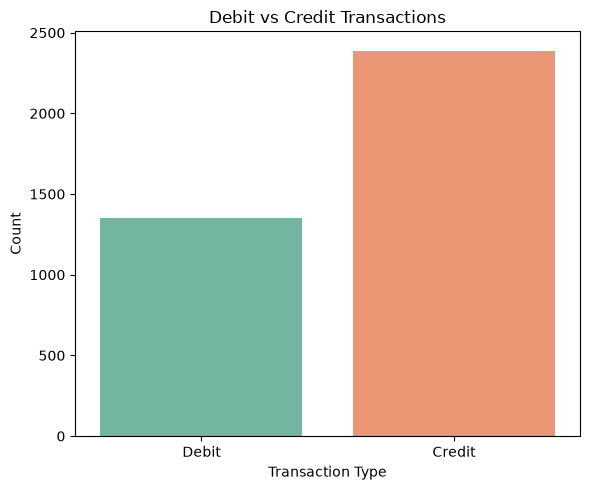

In [30]:
plt.figure(figsize=(6,5))
sns.countplot(x="Transaction Type",data=df,palette="Set2")
plt.title("Debit vs Credit Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Graphs/01_Debit_vs_Credit_Transactions.png",dpi=300,bbox_inches="tight")
plt.show()

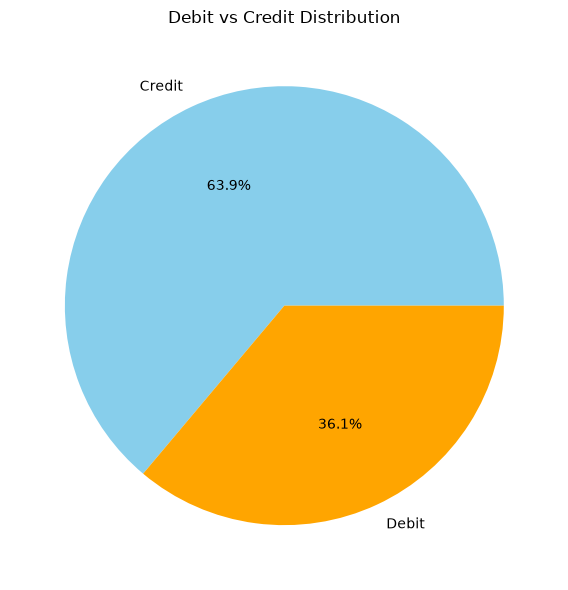

In [31]:
df["Transaction Type"].value_counts().plot(kind="pie",autopct="%1.1f%%",figsize=(6,6),colors=["skyblue","orange"])
plt.ylabel("")
plt.title("Debit vs Credit Distribution")
plt.tight_layout()
plt.savefig("Graphs/02_Debit_vs_Credit_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [32]:
monthly_transactions = (df.groupby("Month")["Transaction Amount"].sum())
monthly_transactions

Month
1     11354259.63
2     10888754.38
3     16568425.71
4     19700341.68
5     28752119.62
6     15229109.79
7     14704994.93
8     14441999.18
9      9383240.34
10    12744351.70
11     9793476.93
12    14025125.29
Name: Transaction Amount, dtype: float64

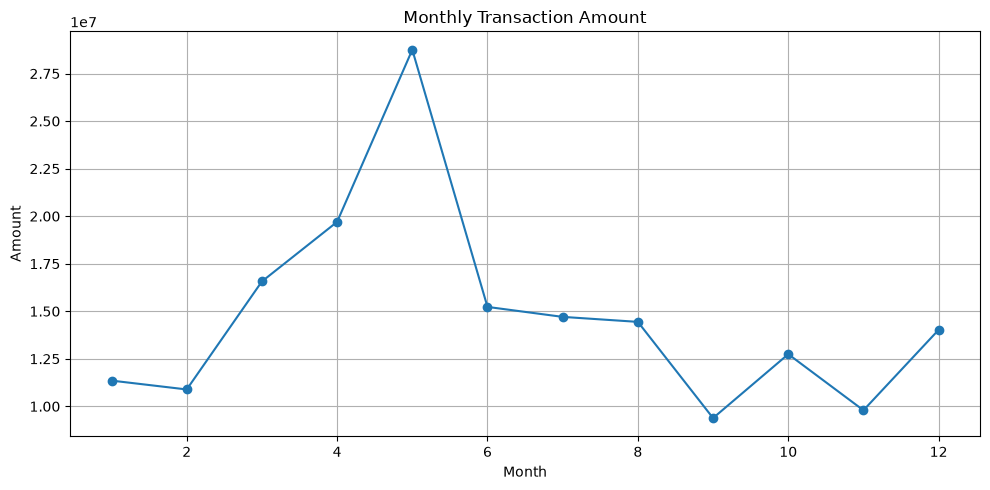

In [33]:
plt.figure(figsize=(10,5))
monthly_transactions.plot(marker="o")
plt.title("Monthly Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.tight_layout()
plt.savefig("Graphs/03_Monthly_Transaction_Amount.png",dpi=300,bbox_inches="tight")
plt.show()

In [34]:
top_desc = (df["Description"].value_counts().head(10))
top_desc

Description
MB:SENT TO PROFICIENT\nTECHNOLOGIES/PROFICIENT PAY    75
CASH DEPOSIT BY GOPINATH @ PORUR BR                   21
MB:v91 payment                                        19
SPAY 9812447652 TRINITY PAYMENT                       19
CLG TO SHREYANSH SALES ICICI BANKING\nCORPOR          11
CASH DEPOSIT BY KARUNAMOORTHY @\nPORUR BR             10
MB:SENT MONEY TO OWN 8850467240                        9
MB:SENT TO K GOPINATHAN                                8
CASH DEPOSIT BY GOPINATH AT CHENNAI -PORUR             8
MB:RECEIVED MONEY FROM OWN 8850467240                  6
Name: count, dtype: int64

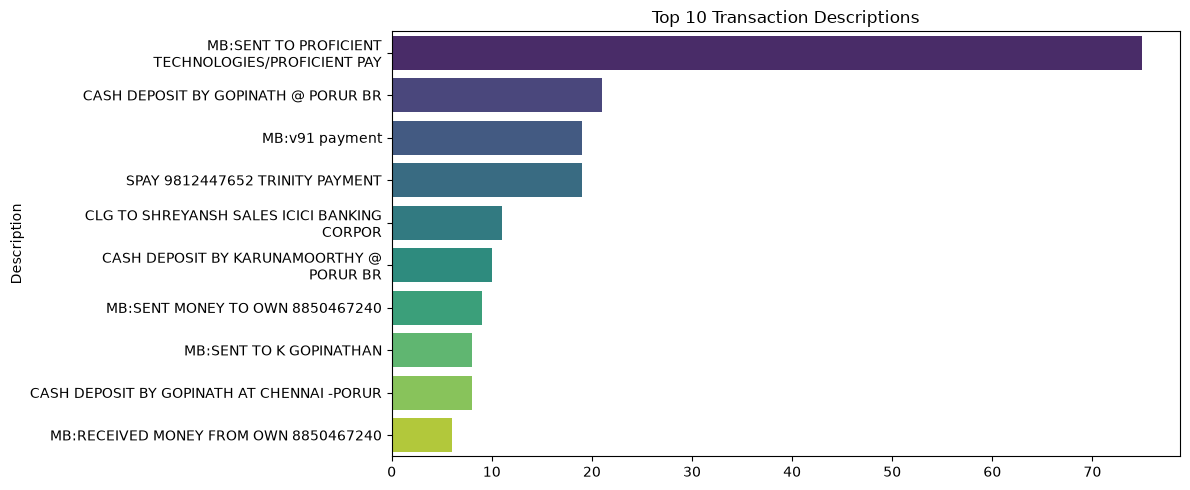

In [35]:
plt.figure(figsize=(12,5))
sns.barplot(x=top_desc.values,y=top_desc.index,palette="viridis")
plt.title("Top 10 Transaction Descriptions")
plt.tight_layout()
plt.savefig("Graphs/04_Top_10_Transaction_Descriptions.png",dpi=300,bbox_inches="tight")
plt.show()

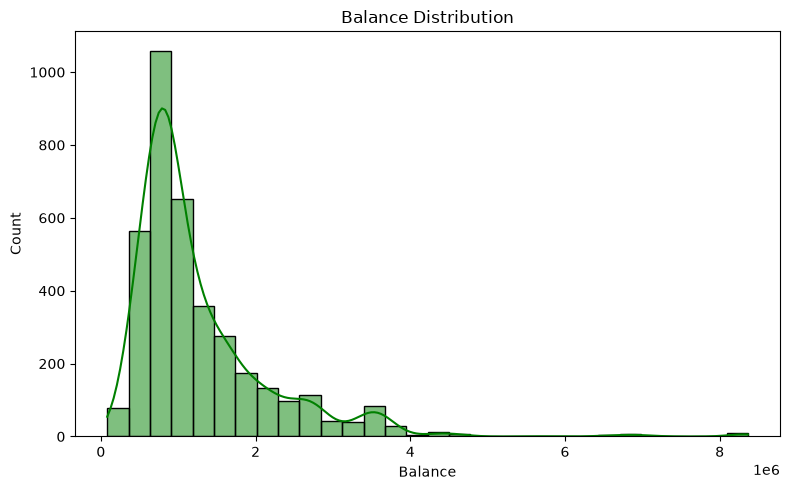

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df["Balance"],bins=30,kde=True,color="green")
plt.title("Balance Distribution")
plt.tight_layout()
plt.savefig("Graphs/05_Balance_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

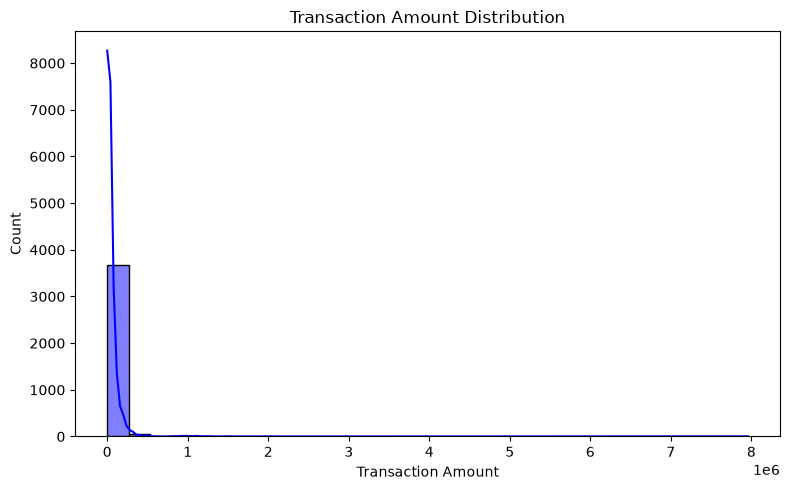

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["Transaction Amount"],bins=30,kde=True,color="blue")
plt.title("Transaction Amount Distribution")
plt.tight_layout()
plt.savefig("Graphs/06_Transaction_Amount_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

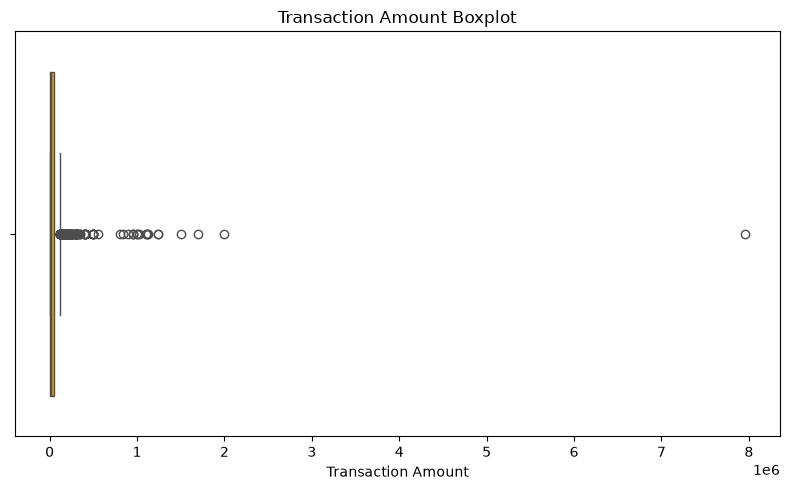

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Transaction Amount"],color="orange")
plt.title("Transaction Amount Boxplot")
plt.tight_layout()
plt.savefig("Graphs/07_Transaction_Amount_Boxplot.png",dpi=300,bbox_inches="tight")
plt.show()

In [39]:
corr = df[["Withdrawal (Dr.)","Deposit (Cr.)","Balance","Transaction Amount"]].corr()
corr

,Withdrawal (Dr.),Deposit (Cr.),Balance,Transaction Amount
Withdrawal (Dr.),1.000000,-0.049150,0.123934,0.436295
Deposit (Cr.),-0.049150,1.000000,0.117699,0.877272
Balance,0.123934,0.117699,1.000000,0.165593
Transaction Amount,0.436295,0.877272,0.165593,1.000000


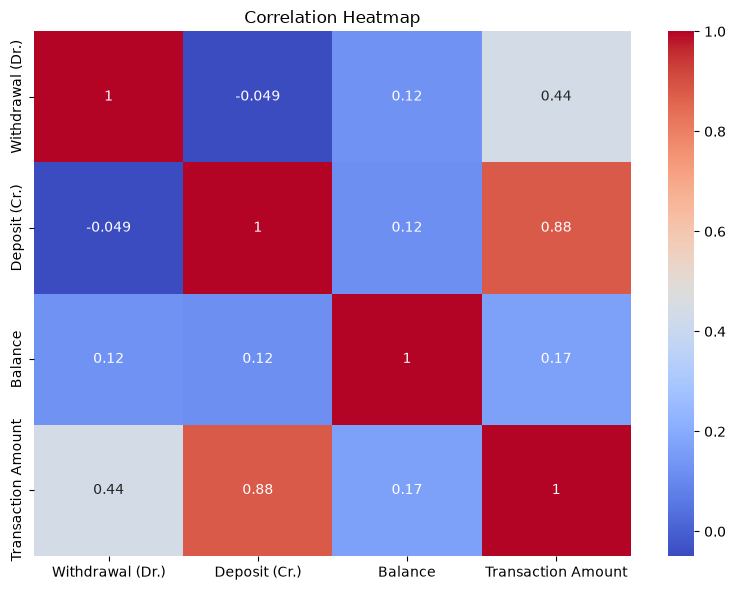

In [40]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("Graphs/08_Correlation_Heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

In [41]:
yearly = (df.groupby("Year")["Transaction Amount"].sum())
yearly

Year
2024    5.656727e+07
2025    1.001812e+08
2026    2.083768e+07
Name: Transaction Amount, dtype: float64

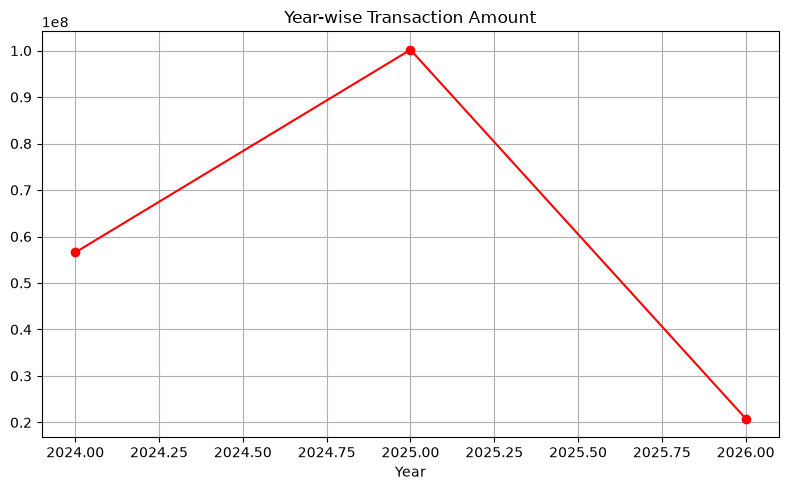

In [42]:
plt.figure(figsize=(8,5))
yearly.plot(marker="o",color="red")
plt.title("Year-wise Transaction Amount")
plt.grid(True)
plt.tight_layout()
plt.savefig("Graphs/09_Year_Wise_Transaction_Amount.png",dpi=300,bbox_inches="tight")
plt.show()

### EDA Summary

The exploratory data analysis revealed several important insights:

- Debit and credit transactions were identified and compared.
- Monthly transaction patterns highlighted seasonal transaction behavior.
- Frequently occurring transaction descriptions were identified.
- Balance and transaction amount distributions were analyzed.
- Correlation between financial variables was examined.
- Potential outliers were visualized using boxplots.

These findings provide a strong foundation for anomaly detection using machine learning algorithms.

# 10. Feature Engineering

Feature Engineering is the process of creating new variables from existing data to improve the performance of machine learning models. In this project, additional features are derived from transaction dates and amounts to enhance anomaly detection.

In [43]:
df.columns

Index(['#', 'Date', 'Description', 'Chq/Ref. No.', 'Withdrawal (Dr.)',
       'Deposit (Cr.)', 'Balance', 'Transaction Amount', 'Transaction Type',
       'Year', 'Month', 'Day', 'Weekday'],
      dtype='str')

In [44]:
# Create Month Name
df["Month Name"] = df["Date"].dt.month_name()
df[["Date", "Month", "Month Name"]].head()

,Date,Month,Month Name
0,2024-04-01,4,April
1,2024-04-01,4,April
2,2024-04-01,4,April
3,2024-04-01,4,April
4,2024-04-01,4,April


In [45]:
# Create Quarter
df["Quarter"] = df["Date"].dt.quarter
df[["Date", "Quarter"]].head()

,Date,Quarter
0,2024-04-01,2
1,2024-04-01,2
2,2024-04-01,2
3,2024-04-01,2
4,2024-04-01,2


In [46]:
# Weekend Transaction
df["Is Weekend"] = df["Weekday"].isin(["Saturday", "Sunday"]).astype(int)
df[["Weekday", "Is Weekend"]].head()

,Weekday,Is Weekend
0,Monday,0
1,Monday,0
2,Monday,0
3,Monday,0
4,Monday,0


In [47]:
# High Value Transaction
df["High Value Transaction"] = np.where(df["Transaction Amount"] >= 100000,1,0)
df["High Value Transaction"].value_counts()

High Value Transaction
0    3248
1     492
Name: count, dtype: int64

In [48]:
# Balance Difference
df["Balance Difference"] = df["Balance"].diff()
df[["Balance", "Balance Difference"]].head()

,Balance,Balance Difference
0,1675768.75,NaN
1,1668348.75,-7420.00
2,1582914.99,-85433.76
3,1652440.99,69526.00
4,1667581.99,15141.00


In [49]:
# Transaction Amount Category
bins = [0, 10000, 50000, 100000, np.inf]
labels = ["Low","Medium","High","Very High"]
df["Amount Category"] = pd.cut(df["Transaction Amount"],bins=bins,labels=labels,include_lowest=True)
df["Amount Category"].value_counts()

Amount Category
Medium       1435
Low          1432
High          516
Very High     357
Name: count, dtype: int64

In [50]:
new_features = ["Transaction Amount","Transaction Type","Month Name",
                "Quarter","Is Weekend","High Value Transaction","Balance Difference","Amount Category"]
df[new_features].head()

,Transaction Amount,Transaction Type,Month Name,Quarter,Is Weekend,High Value Transaction,Balance Difference,Amount Category
0,300000.00,Debit,April,2,0,1,NaN,Very High
1,7420.00,Credit,April,2,0,0,-7420.00,Low
2,85433.76,Credit,April,2,0,0,-85433.76,High
3,69526.00,Debit,April,2,0,0,69526.00,High
4,15141.00,Debit,April,2,0,0,15141.00,Medium


In [51]:
df[new_features].isnull().sum()

Transaction Amount        0
Transaction Type          0
Month Name                0
Quarter                   0
Is Weekend                0
High Value Transaction    0
Balance Difference        1
Amount Category           0
dtype: int64

In [52]:
df["Balance Difference"] = df["Balance Difference"].fillna(0)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3740 entries, 0 to 3739
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   #                       3740 non-null   object        
 1   Date                    3740 non-null   datetime64[us]
 2   Description             3740 non-null   str           
 3   Chq/Ref. No.            3541 non-null   str           
 4   Withdrawal (Dr.)        3740 non-null   float64       
 5   Deposit (Cr.)           3740 non-null   float64       
 6   Balance                 3740 non-null   float64       
 7   Transaction Amount      3740 non-null   float64       
 8   Transaction Type        3740 non-null   str           
 9   Year                    3740 non-null   int32         
 10  Month                   3740 non-null   int32         
 11  Day                     3740 non-null   int32         
 12  Weekday                 3740 non-null   str           
 13 

### Feature Engineering Summary

The following new features were created:

- Month Name
- Quarter
- Weekend Transaction Indicator
- High Value Transaction Flag
- Balance Difference
- Transaction Amount Category

These engineered features provide additional information that helps the anomaly detection model identify unusual transaction patterns more effectively.

# 11. Feature Selection

Feature selection is the process of choosing the most relevant variables for machine learning. Since Isolation Forest works with numerical features, only meaningful numerical columns are selected for anomaly detection.

In [54]:
# Select Numerical Features for Machine Learning
features = ["Withdrawal (Dr.)","Deposit (Cr.)","Balance","Transaction Amount","Balance Difference",
    "Month","Day","Quarter","High Value Transaction","Is Weekend"]
X = df[features]
X.head()

,Withdrawal (Dr.),Deposit (Cr.),Balance,Transaction Amount,Balance Difference,Month,Day,Quarter,High Value Transaction,Is Weekend
0,300000.0,0.00,1675768.75,300000.00,0.00,4,1,2,1,0
1,0.0,7420.00,1668348.75,7420.00,-7420.00,4,1,2,0,0
2,0.0,85433.76,1582914.99,85433.76,-85433.76,4,1,2,0,0
3,69526.0,0.00,1652440.99,69526.00,69526.00,4,1,2,0,0
4,15141.0,0.00,1667581.99,15141.00,15141.00,4,1,2,0,0


In [55]:
print("Selected Features:")
for feature in features:
   print("-", feature)

Selected Features:
- Withdrawal (Dr.)
- Deposit (Cr.)
- Balance
- Transaction Amount
- Balance Difference
- Month
- Day
- Quarter
- High Value Transaction
- Is Weekend


In [56]:
X.isnull().sum()

Withdrawal (Dr.)          0
Deposit (Cr.)             0
Balance                   0
Transaction Amount        0
Balance Difference        0
Month                     0
Day                       0
Quarter                   0
High Value Transaction    0
Is Weekend                0
dtype: int64

# 12. Data Scaling

Machine learning algorithms perform better when numerical features are on a similar scale. StandardScaler standardizes the data by removing the mean and scaling to unit variance.

In [57]:
# Initialize StandardScaler
scaler = StandardScaler()

In [58]:
# Scale Features
X_scaled = scaler.fit_transform(X)

In [59]:
# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled,columns=features)
X_scaled.head()

,Withdrawal (Dr.),Deposit (Cr.),Balance,Transaction Amount,Balance Difference,Month,Day,Quarter,High Value Transaction,Is Weekend
0,3.535931,-0.163873,0.432388,1.551645,0.001475,-0.713009,-1.639982,-0.424651,2.569363,-0.579409
1,-0.299928,-0.113263,0.424375,-0.246175,-0.042794,-0.713009,-1.639982,-0.424651,-0.389202,-0.579409
2,-0.299928,0.418845,0.332107,0.233197,-0.508239,-0.713009,-1.639982,-0.424651,-0.389202,-0.579409
3,0.589045,-0.163873,0.407195,0.135448,0.416281,-0.713009,-1.639982,-0.424651,-0.389202,-0.579409
4,-0.106332,-0.163873,0.423547,-0.198732,0.091809,-0.713009,-1.639982,-0.424651,-0.389202,-0.579409


In [60]:
X_scaled.describe().round(2)

,Withdrawal (Dr.),Deposit (Cr.),Balance,Transaction Amount,Balance Difference,Month,Day,Quarter,High Value Transaction,Is Weekend
count,3740.00,3740.00,3740.00,3740.00,3740.00,3740.00,3740.00,3740.00,3740.00,3740.00
mean,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.30,-0.16,-1.29,-0.29,-10.95,-1.60,-1.64,-1.33,-0.39,-0.58
25%,-0.30,-0.16,-0.60,-0.26,-0.10,-1.01,-0.85,-1.33,-0.39,-0.58
50%,-0.30,-0.13,-0.34,-0.18,0.00,-0.12,-0.06,-0.42,-0.39,-0.58
75%,-0.17,-0.02,0.29,0.01,0.11,0.76,0.85,0.48,-0.39,1.73
max,21.44,54.12,7.66,48.61,47.48,1.64,1.75,1.38,2.57,1.73


In [61]:
print("Original Shape :", X.shape)
print("Scaled Shape   :", X_scaled.shape)

Original Shape : (3740, 10)
Scaled Shape   : (3740, 10)


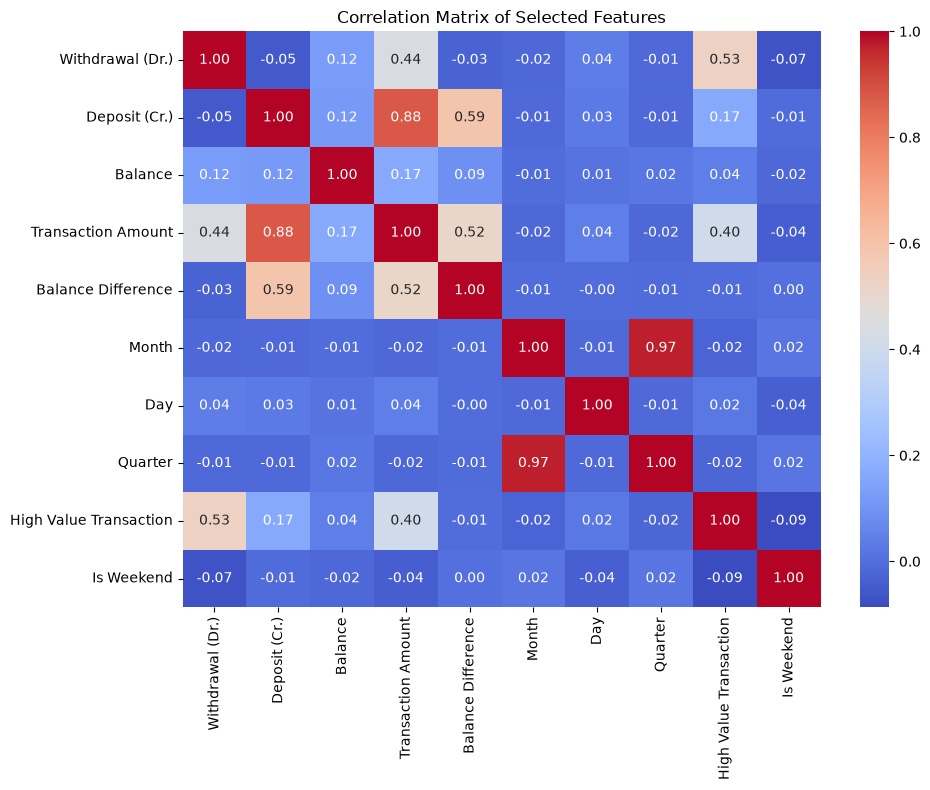

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_scaled.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.savefig("Graphs/10_Correlation_Matrix_Of_Seleted_Features.png",dpi=300,bbox_inches="tight")
plt.show()

### Feature Selection & Scaling Summary

The following preprocessing steps were completed:

- Selected the numerical features required for anomaly detection.
- Standardized all selected features using StandardScaler.
- Verified that the scaled dataset retained the same dimensions.
- Examined the relationships between the selected features using a correlation heatmap.

The scaled dataset is now ready for training the Isolation Forest anomaly detection model.

# 13. Anomaly Detection Using Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm designed to identify anomalies in a dataset. It isolates unusual observations by randomly selecting features and splitting values. Transactions that are isolated more quickly are considered anomalous.

In this project, Isolation Forest is used to detect unusual bank transactions based on selected financial features.

In [63]:
# Train Isolation Forest Model
iso_forest = IsolationForest(n_estimators=100,contamination=0.02,random_state=42)
iso_forest.fit(X_scaled)
print("Isolation Forest Model Trained Successfully")

Isolation Forest Model Trained Successfully


In [64]:
# Predict Anomalies
df["Anomaly"] = iso_forest.predict(X_scaled)
df["Anomaly"].head()

0    1
1    1
2    1
3    1
4    1
Name: Anomaly, dtype: int64

In [65]:
# Convert Labels
df["Anomaly Label"] = df["Anomaly"].map({1: "Normal",-1: "Anomaly"})
df[["Anomaly", "Anomaly Label"]].head()

,Anomaly,Anomaly Label
0,1,Normal
1,1,Normal
2,1,Normal
3,1,Normal
4,1,Normal


In [66]:
# Count Normal vs Anomaly
df["Anomaly Label"].value_counts()

Anomaly Label
Normal     3665
Anomaly      75
Name: count, dtype: int64

In [67]:
# Percentage of Anomalies
anomaly_percentage = (df["Anomaly Label"].value_counts(normalize=True)* 100)
anomaly_percentage

Anomaly Label
Normal     97.994652
Anomaly     2.005348
Name: proportion, dtype: float64

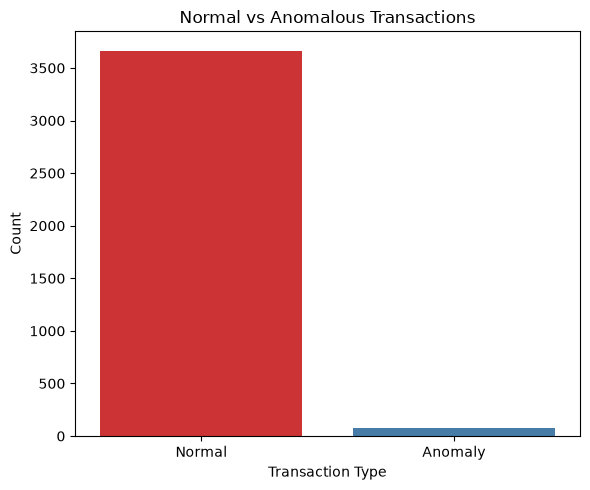

In [68]:
plt.figure(figsize=(6,5))
sns.countplot(x="Anomaly Label",data=df,palette="Set1")
plt.title("Normal vs Anomalous Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Graphs/11_Transaction_Type.png",dpi=300,bbox_inches="tight")
plt.show()

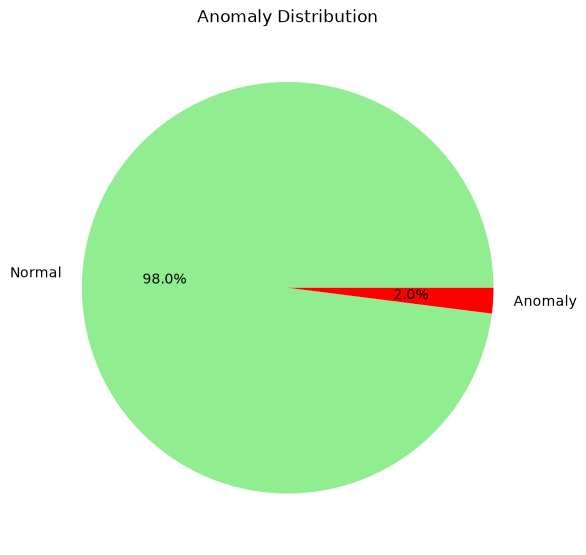

In [69]:
df["Anomaly Label"].value_counts().plot(kind="pie",autopct="%1.1f%%",figsize=(6,6),colors=["lightgreen", "red"])
plt.ylabel("")
plt.title("Anomaly Distribution")
plt.tight_layout()
plt.savefig("Graphs/12_Anomaly_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [70]:
anomalies = df[df["Anomaly Label"] == "Anomaly"]
anomalies.head(10)

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance,Transaction Amount,Transaction Type,Year,Month,Day,Weekday,Month Name,Quarter,Is Weekend,High Value Transaction,Balance Difference,Amount Category,Anomaly,Anomaly Label
39,40,2024-04-13,IB: FUND TRANSFER FROM T S P ENTERPRISES,IB,0.00,200000.0,1167907.04,200000.00,Credit,2024,4,13,Saturday,April,2,1,1,-200000.00,Very High,-1,Anomaly
40,41,2024-04-13,SentIMPS410416704986arivazhaga/UBINX795\n2/PON...,IMPS-410416634753,250000.00,0.0,1417907.04,250000.00,Debit,2024,4,13,Saturday,April,2,1,1,250000.00,Very High,-1,Anomaly
97,98,2024-04-25,Ins Debit A\c GLN 2787819 dt 25/04/24,CORE-1838457190,556790.76,0.0,1926521.70,556790.76,Debit,2024,4,25,Thursday,April,2,0,1,556790.76,Very High,-1,Anomaly
102,103,2024-04-27,NEFT N118240526854000 TSP SUPER CYCLE\nWORKS E...,NEFTINW-0838802511,0.00,400000.0,1463257.01,400000.00,Credit,2024,4,27,Saturday,April,2,1,1,-400000.00,Very High,-1,Anomaly
107,108,2024-04-28,NEFT N119240639134002 TSP SUPER CYCLE\nWORKS E...,NEFTINW-0839448134,0.00,500000.0,955528.05,500000.00,Credit,2024,4,28,Sunday,April,2,1,1,-500000.00,Very High,-1,Anomaly
133,134,2024-05-04,SentIMPS412511188256arivazhaga/UBINX795\n2/PON...,IMPS-412511787135,300000.00,0.0,1418965.47,300000.00,Debit,2024,5,4,Saturday,May,2,1,1,300000.00,Very High,-1,Anomaly
251,252,2024-06-01,MB:v91 payment,000398886508,200000.00,0.0,1143199.64,200000.00,Debit,2024,6,1,Saturday,June,2,1,1,200000.00,Very High,-1,Anomaly
284,285,2024-06-05,CASH DEPOSIT BY KARUNAMOOTHY @ PORUR\nBR,NaN,0.00,390000.0,1048618.49,390000.00,Credit,2024,6,5,Wednesday,June,2,0,1,-390000.00,Very High,-1,Anomaly
597,598,2024-08-01,MB:RECEIVED FROM KKARUNAMOORTHY\n./BONDHUR SID...,MB-998642996359,0.00,500000.0,612979.60,500000.00,Credit,2024,8,1,Thursday,August,3,0,1,-500000.00,Very High,-1,Anomaly
762,763,2024-08-30,MB:SENT TO PROFICIENT TECHNOLOGIES/PROFICIENT PAY,MB-998626326528,300000.00,0.0,752952.02,300000.00,Debit,2024,8,30,Friday,August,3,0,1,300000.00,Very High,-1,Anomaly


In [71]:
print("Total Anomalous Transactions :", len(anomalies))

Total Anomalous Transactions : 75


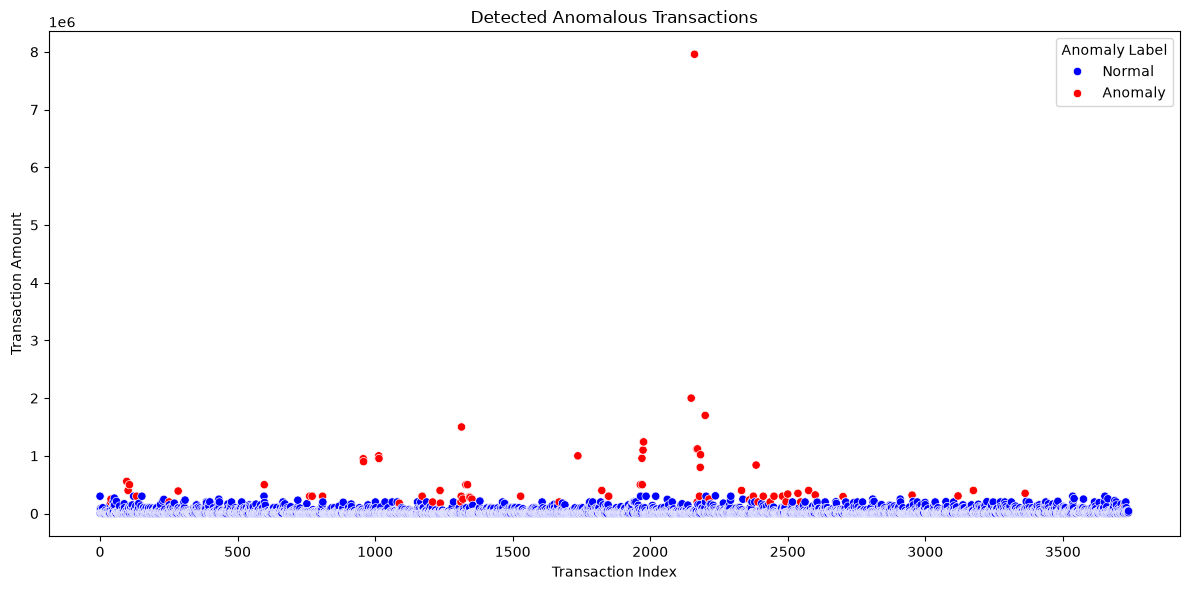

In [72]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=df.index,y="Transaction Amount",hue="Anomaly Label",
                data=df,palette={"Normal": "blue","Anomaly": "red"})
plt.title("Detected Anomalous Transactions")
plt.xlabel("Transaction Index")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.savefig("Graphs/13_Detected_Anomalous_Transactions.png",dpi=300,bbox_inches="tight")
plt.show()

In [73]:
joblib.dump(iso_forest,"IsolationForest_BankTransaction_Model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [74]:
joblib.dump(scaler,"StandardScaler.pkl")
print("Scaler Saved Successfully")

Scaler Saved Successfully


### Machine Learning Summary

The Isolation Forest model was trained using the scaled numerical transaction features. Each transaction was classified as either **Normal** or **Anomaly**. The detected anomalies represent unusual transaction patterns that may require further investigation.

The trained model and scaler were saved for future use in detecting anomalies on new transaction data.

# 14. Model Evaluation

The performance of the Isolation Forest model is evaluated by analyzing the number of normal and anomalous transactions detected. Since anomaly detection is an unsupervised learning task, evaluation focuses on anomaly distribution and business interpretation rather than prediction accuracy.

In [75]:
# Total Transaction
print("Total Transactions :", len(df))

Total Transactions : 3740


In [76]:
# Normal Transactions
normal = df[df["Anomaly Label"] == "Normal"]
print("Normal Transactions :", len(normal))

Normal Transactions : 3665


In [77]:
# Anomalous Transactions
anomalies = df[df["Anomaly Label"] == "Anomaly"]
print("Anomalous Transactions :", len(anomalies))

Anomalous Transactions : 75


In [78]:
# Percentage
percentage = (len(anomalies) / len(df)) * 100
print(f"Anomaly Percentage : {percentage:.2f}%")

Anomaly Percentage : 2.01%


In [79]:
# Average Transaction Amount
df.groupby("Anomaly Label")["Transaction Amount"].mean()

Anomaly Label
Anomaly    612523.200667
Normal      35920.043419
Name: Transaction Amount, dtype: float64

In [80]:
# Average Balance
df.groupby("Anomaly Label")["Balance"].mean()

Anomaly Label
Anomaly    2.133504e+06
Normal     1.257848e+06
Name: Balance, dtype: float64

In [81]:
# Transaction Type Distribution
pd.crosstab(df["Transaction Type"],df["Anomaly Label"])

Anomaly Label,Anomaly,Normal
Transaction Type,,
Credit,29,2360
Debit,46,1305


In [82]:
# High Value Transactions
pd.crosstab(df["High Value Transaction"],df["Anomaly Label"])

Anomaly Label,Anomaly,Normal
High Value Transaction,,
0,0,3248
1,75,417


In [83]:
monthly_anomalies = (anomalies.groupby("Month Name").size().sort_values(ascending=False))
monthly_anomalies

Month Name
December     14
April        12
May          11
July          9
August        7
June          5
October       5
March         4
November      3
January       2
September     2
February      1
dtype: int64

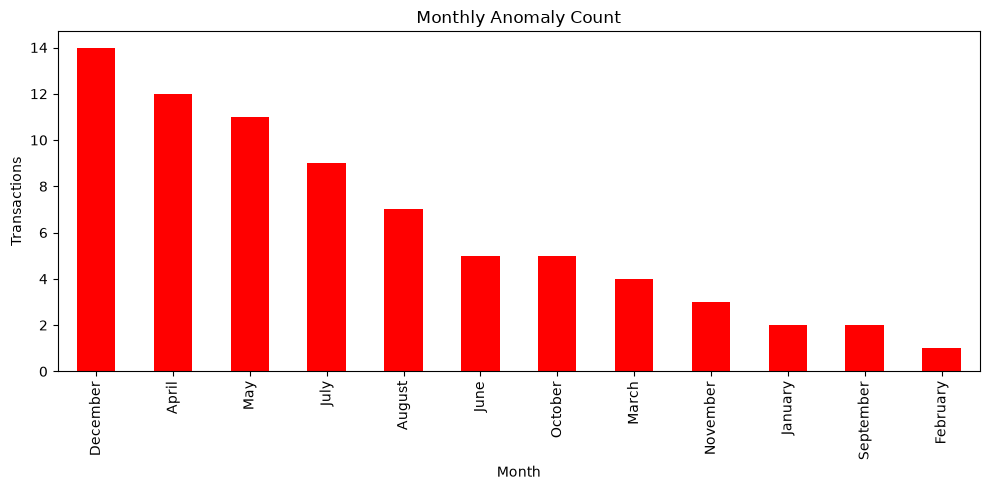

In [84]:
plt.figure(figsize=(10,5))
monthly_anomalies.plot(kind="bar",color="red")
plt.title("Monthly Anomaly Count")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.tight_layout()
plt.savefig("Graphs/14_Monthly_Anomaly_Count.png",dpi=300,bbox_inches="tight")
plt.show()

In [85]:
anomalies.sort_values(
    "Transaction Amount",
    ascending=False
)[[
    "Date",
    "Description",
    "Transaction Amount",
    "Balance"
]].head(10)

,Date,Description,Transaction Amount,Balance
2161,2025-05-26,FUNDS TRANSFER FROM RA- LOAN\nDISBURSEMENT AC,7958000.00,8275856.25
2149,2025-05-23,FUNDS TRANSFER FROM RA- LOAN\nDISBURSEMENT AC,2000000.00,82142.20
2200,2025-05-30,BRB:Sent RTGS KKBKR52025053000809891/K\nKARUNA...,1700000.00,2754348.19
1314,2024-12-24,0472 / 493833 / TSP SUPER CYCLE WORKS /\n88504...,1500000.00,1344645.40
1976,2025-04-22,Ac xfr from gl 11200 to 11201,1241416.85,1241416.85
1975,2025-04-22,Ac xfr from gl 11200 to 11201,1241416.85,2482833.70
2172,2025-05-27,FUND TRANSFER TO K GOPINATHAN,1120000.00,6992189.86
2169,2025-05-27,BRB:Sent RTGS\nKKBKR52025052700703178/KMBF NID...,1116042.00,7196147.86
2170,2025-05-27,RTGS CIUBR52025052700407119\nKUMBAKONAM MUTUAL B,1116042.00,8312189.86
1974,2025-04-22,RTGS CIUBR52025042200407565\nKUMBAKONAM MUTUAL B,1100000.00,1241416.85


In [86]:
df.sort_values(
    "Withdrawal (Dr.)",
    ascending=False
)[[
    "Date",
    "Description",
    "Withdrawal (Dr.)"
]].head(10)

,Date,Description,Withdrawal (Dr.)
2200,2025-05-30,BRB:Sent RTGS KKBKR52025053000809891/K\nKARUNA...,1700000.00
1314,2024-12-24,0472 / 493833 / TSP SUPER CYCLE WORKS /\n88504...,1500000.00
1975,2025-04-22,Ac xfr from gl 11200 to 11201,1241416.85
2172,2025-05-27,FUND TRANSFER TO K GOPINATHAN,1120000.00
2169,2025-05-27,BRB:Sent RTGS\nKKBKR52025052700703178/KMBF NID...,1116042.00
2183,2025-05-28,FUND TRANSER TO T S P ENTERPRISES,1020000.00
1013,2024-10-19,Sent RTGS\nKKBKR52024101900797498/JAYAKKODI PI,1000000.00
1970,2025-04-22,Sent NEFT KKBKH25112932424/K\nGOPINATHAN/KOTAK,956989.00
958,2024-10-07,Sent RTGS\nKKBKR52024100700694507/GOKULNATH S/,900000.00
2182,2025-05-28,BRB:Sent RTGS\nKKBKR52025052800861655/TSP SUPE...,800000.00


In [87]:
df.sort_values(
    "Deposit (Cr.)",
    ascending=False
)[[
    "Date",
    "Description",
    "Deposit (Cr.)"
]].head(10)

,Date,Description,Deposit (Cr.)
2161,2025-05-26,FUNDS TRANSFER FROM RA- LOAN\nDISBURSEMENT AC,7958000.00
2149,2025-05-23,FUNDS TRANSFER FROM RA- LOAN\nDISBURSEMENT AC,2000000.00
1976,2025-04-22,Ac xfr from gl 11200 to 11201,1241416.85
2170,2025-05-27,RTGS CIUBR52025052700407119\nKUMBAKONAM MUTUAL B,1116042.00
1974,2025-04-22,RTGS CIUBR52025042200407565\nKUMBAKONAM MUTUAL B,1100000.00
1737,2025-03-12,RTGS SVCBR52025031200433744\nVENKATESHAN V SVCB0,1000000.00
1014,2024-10-19,GOLD LOAN DISB FOR GLN3592978 K\nGOPINATHAN,953165.00
957,2024-10-07,CASH DEPOSIT BY GOPINATH @ PORUR BR,950000.00
2385,2025-07-03,RTGS IDIBR52025070346257545 SHRI\nSUBRAMANYA SWA,840000.00
1964,2025-04-21,NEFT N111250163236008 TSP SUPER CYCLE\nWORKS E...,500000.00


# 15. Business Insights

Based on the analysis of the bank transaction dataset, the following insights were observed:

- The majority of transactions were classified as normal.
- A small percentage of transactions were detected as anomalies.
- High-value transactions were more likely to be identified as unusual.
- Monthly transaction volumes varied throughout the analysis period.
- Transaction descriptions revealed common banking activities such as ATM withdrawals, UPI payments, IMPS transfers, and salary credits.
- Isolation Forest successfully identified transactions that differed significantly from typical transaction patterns.

These insights can help financial institutions monitor transaction behavior, improve fraud detection, and support risk management.

### Model Evaluation Summary

The Isolation Forest algorithm effectively analyzed the bank transaction dataset and identified unusual transactions without requiring labeled data. The generated anomaly labels provide a basis for further investigation and can support fraud detection and financial risk monitoring.

# 16. Conclusion

This project successfully analyzed bank transaction data using machine learning techniques. The dataset was cleaned, preprocessed, and explored through comprehensive exploratory data analysis (EDA). New features were engineered to improve data representation and support anomaly detection.

The Isolation Forest algorithm was applied to identify unusual transactions without requiring labeled data. The model effectively distinguished normal transactions from anomalous ones, providing valuable insights into transaction behavior. The findings demonstrate how machine learning can assist financial institutions in monitoring transactions, identifying suspicious activities, and improving operational efficiency.

Overall, the project highlights the importance of data analytics and anomaly detection in banking systems and provides a scalable framework for future financial analytics applications.

# 17. Future Scope

The project can be extended in several ways to enhance its capabilities:

- Implement real-time anomaly detection for live banking transactions.
- Compare multiple anomaly detection algorithms such as One-Class SVM, Local Outlier Factor (LOF), and Autoencoders.
- Develop fraud risk scoring models for customer transactions.
- Build an interactive Power BI or Tableau dashboard for transaction monitoring.
- Integrate deep learning techniques for improved anomaly detection on large-scale datasets.
- Deploy the trained model as a web application using Flask, FastAPI, or Streamlit.
- Incorporate transaction location, merchant category, and customer behavior for more advanced analysis.

# 18. References

The following resources and libraries were used during the development of this project:

1. Python Programming Language
2. Pandas Documentation
3. NumPy Documentation
4. Matplotlib Documentation
5. Seaborn Documentation
6. Scikit-learn Documentation
7. Jupyter Notebook
8. Isolation Forest Algorithm (Scikit-learn)
9. Banking Transaction Analytics and Machine Learning Research Articles

In [88]:
# Save the Final Dataset
df.to_csv("Bank_Transaction_Analytics_Final.csv",index=False)
print("Final Dataset Saved Successfully")

Final Dataset Saved Successfully


In [89]:
# Save as Excel
df.to_excel("Bank_Transaction_Analytics_Final.xlsx",index=False)
print("Excel File Saved Successfully")

Excel File Saved Successfully


In [90]:
type(iso_forest)

sklearn.ensemble._iforest.IsolationForest

In [91]:
type(scaler)

sklearn.preprocessing._data.StandardScaler

In [92]:
# Display Final Dataset
df.head()

,#,Date,Description,Chq/Ref. No.,Withdrawal (Dr.),Deposit (Cr.),Balance,Transaction Amount,Transaction Type,Year,Month,Day,Weekday,Month Name,Quarter,Is Weekend,High Value Transaction,Balance Difference,Amount Category,Anomaly,Anomaly Label
0,1,2024-04-01,MB:v91 payment,000388119179,300000.0,0.00,1675768.75,300000.00,Debit,2024,4,1,Monday,April,2,0,1,0.00,Very High,1,Normal
1,2,2024-04-01,Recd:IMPS/409209339954/ONE97COMMU/KKB\nK/X0961...,IMPS-409209469333,0.0,7420.00,1668348.75,7420.00,Credit,2024,4,1,Monday,April,2,0,0,-7420.00,Low,1,Normal
2,3,2024-04-01,KotakPayout-079058004630063-010424,NaN,0.0,85433.76,1582914.99,85433.76,Credit,2024,4,1,Monday,April,2,0,0,-85433.76,High,1,Normal
3,4,2024-04-01,MB:vinayaga bills payments,000388166922,69526.0,0.00,1652440.99,69526.00,Debit,2024,4,1,Monday,April,2,0,0,69526.00,High,1,Normal
4,5,2024-04-01,Int.Coll:9500000306:02-03-2024 to 01-04-2024,NaN,15141.0,0.00,1667581.99,15141.00,Debit,2024,4,1,Monday,April,2,0,0,15141.00,Medium,1,Normal


In [93]:
# Final Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3740 entries, 0 to 3739
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   #                       3740 non-null   object        
 1   Date                    3740 non-null   datetime64[us]
 2   Description             3740 non-null   str           
 3   Chq/Ref. No.            3541 non-null   str           
 4   Withdrawal (Dr.)        3740 non-null   float64       
 5   Deposit (Cr.)           3740 non-null   float64       
 6   Balance                 3740 non-null   float64       
 7   Transaction Amount      3740 non-null   float64       
 8   Transaction Type        3740 non-null   str           
 9   Year                    3740 non-null   int32         
 10  Month                   3740 non-null   int32         
 11  Day                     3740 non-null   int32         
 12  Weekday                 3740 non-null   str           
 13 

In [94]:
print("=" * 60)
print("BANK TRANSACTION ANALYTICS AND ANOMALY DETECTION")
print("=" * 60)

print(f"Total Transactions        : {len(df)}")
print(f"Total Features           : {df.shape[1]}")
print(f"Detected Anomalies       : {len(df[df['Anomaly Label']=='Anomaly'])}")
print(f"Normal Transactions      : {len(df[df['Anomaly Label']=='Normal'])}")

print("=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

BANK TRANSACTION ANALYTICS AND ANOMALY DETECTION
Total Transactions        : 3740
Total Features           : 21
Detected Anomalies       : 75
Normal Transactions      : 3665
PROJECT COMPLETED SUCCESSFULLY


# 19. Model Deployment

The trained Isolation Forest model and the fitted `StandardScaler` were saved earlier in this notebook (`IsolationForest_BankTransaction_Model.pkl` and `StandardScaler.pkl`). This section turns those saved artifacts into a working web application so that new transactions can be checked for anomalies without re-running the notebook.

The deployment is built with **Streamlit**, a lightweight Python framework for turning data science scripts into shareable web apps. Two ways to interact with the model are provided:

- **Single Transaction Check** — manually enter one transaction's details and get an instant Normal / Anomaly verdict.
- **Batch Scan (CSV Upload)** — upload a CSV of transactions and get anomaly labels for every row, downloadable as a results file.

The next cells generate the deployment files (`app.py`, `requirements.txt`) directly into the notebook's working directory.

In [95]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from datetime import date

st.set_page_config(page_title="Bank Transaction Anomaly Detector", page_icon="🏦", layout="wide")

FEATURES = ["Withdrawal (Dr.)", "Deposit (Cr.)", "Balance", "Transaction Amount",
            "Balance Difference", "Month", "Day", "Quarter",
            "High Value Transaction", "Is Weekend"]

@st.cache_resource
def load_artifacts():
    model = joblib.load("IsolationForest_BankTransaction_Model.pkl")
    scaler = joblib.load("StandardScaler.pkl")
    return model, scaler

model, scaler = load_artifacts()

st.title("🏦 Bank Transaction Analytics & Anomaly Detection")
st.caption("Isolation Forest model trained on bank statement data — flags unusual transactions in real time.")

tab1, tab2 = st.tabs(["🔍 Check a Single Transaction", "📂 Batch Scan (CSV Upload)"])


def engineer_single(txn_date, withdrawal, deposit, balance, previous_balance):
    transaction_amount = withdrawal + deposit
    balance_difference = balance - previous_balance
    month = txn_date.month
    day = txn_date.day
    quarter = (month - 1) // 3 + 1
    is_weekend = int(txn_date.weekday() >= 5)
    high_value = int(transaction_amount >= 100000)
    row = pd.DataFrame([{
        "Withdrawal (Dr.)": withdrawal,
        "Deposit (Cr.)": deposit,
        "Balance": balance,
        "Transaction Amount": transaction_amount,
        "Balance Difference": balance_difference,
        "Month": month,
        "Day": day,
        "Quarter": quarter,
        "High Value Transaction": high_value,
        "Is Weekend": is_weekend,
    }])
    return row[FEATURES]


with tab1:
    st.subheader("Enter Transaction Details")
    col1, col2 = st.columns(2)
    with col1:
        txn_date = st.date_input("Transaction Date", value=date.today())
        withdrawal = st.number_input("Withdrawal (Dr.)", min_value=0.0, value=0.0, step=100.0)
        deposit = st.number_input("Deposit (Cr.)", min_value=0.0, value=0.0, step=100.0)
    with col2:
        balance = st.number_input("Balance After Transaction", value=0.0, step=100.0)
        previous_balance = st.number_input("Previous Balance (used for Balance Difference)", value=balance, step=100.0)

    if st.button("Analyze Transaction", type="primary"):
        row = engineer_single(txn_date, withdrawal, deposit, balance, previous_balance)
        scaled = scaler.transform(row)
        pred = model.predict(scaled)[0]
        score = model.decision_function(scaled)[0]
        label = "🚨 Anomaly" if pred == -1 else "✅ Normal"
        c1, c2 = st.columns(2)
        c1.metric("Result", label)
        c2.metric("Anomaly Score", f"{score:.4f}", help="Lower (more negative) scores are more anomalous.")
        st.dataframe(row, use_container_width=True)

with tab2:
    st.subheader("Upload a Bank Statement CSV")
    st.write("Required columns: `Date`, `Withdrawal (Dr.)`, `Deposit (Cr.)`, `Balance`")
    file = st.file_uploader("Choose CSV file", type=["csv"])
    if file is not None:
        raw = pd.read_csv(file)
        raw["Date"] = pd.to_datetime(raw["Date"])
        raw = raw.sort_values("Date").reset_index(drop=True)
        raw["Transaction Amount"] = raw["Withdrawal (Dr.)"] + raw["Deposit (Cr.)"]
        raw["Balance Difference"] = raw["Balance"].diff().fillna(0)
        raw["Month"] = raw["Date"].dt.month
        raw["Day"] = raw["Date"].dt.day
        raw["Quarter"] = raw["Date"].dt.quarter
        raw["Is Weekend"] = (raw["Date"].dt.dayofweek >= 5).astype(int)
        raw["High Value Transaction"] = np.where(raw["Transaction Amount"] >= 100000, 1, 0)

        X = raw[FEATURES]
        X_scaled = scaler.transform(X)
        raw["Anomaly"] = model.predict(X_scaled)
        raw["Anomaly Label"] = raw["Anomaly"].map({1: "Normal", -1: "Anomaly"})

        n_anomaly = int((raw["Anomaly Label"] == "Anomaly").sum())
        st.success(f"Scanned {len(raw)} transactions — found {n_anomaly} anomalies.")
        st.dataframe(raw, use_container_width=True)
        st.download_button(
            "Download Results as CSV",
            raw.to_csv(index=False).encode("utf-8"),
            "anomaly_results.csv",
            "text/csv",
        )

st.sidebar.header("About")
st.sidebar.write(
    "This app uses an Isolation Forest model trained on historical bank transactions "
    "to flag statistically unusual activity for further review. It is a decision-support "
    "tool, not a final fraud determination."
)

Overwriting app.py


In [96]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Overwriting requirements.txt


## Deployment Instructions

**1. Run locally**
```bash
pip install -r requirements.txt
streamlit run app.py
```
This opens the app at `http://localhost:8501`. Make sure `IsolationForest_BankTransaction_Model.pkl` and `StandardScaler.pkl` are in the same folder as `app.py` (they already are, since they were saved earlier in this notebook).

**2. Deploy for free — Streamlit Community Cloud**
1. Push this folder (containing `app.py`, `requirements.txt`, and the two `.pkl` files) to a GitHub repository.
2. Go to [share.streamlit.io](https://share.streamlit.io), sign in with GitHub, and click **New app**.
3. Select the repository/branch and set the main file path to `app.py`.
4. Click **Deploy** — a public URL is generated automatically.

**3. Deploy with Docker (any cloud provider)**
The next cell writes a `Dockerfile` that containerizes the app so it can be deployed to services such as AWS, Azure, GCP, or Render.

In [97]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app
COPY . /app

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Overwriting Dockerfile


### Deployment Summary

- **Artifacts used:** `IsolationForest_BankTransaction_Model.pkl`, `StandardScaler.pkl`
- **Interface:** Streamlit web app with single-transaction and batch-CSV modes
- **Output:** Normal / Anomaly label plus an anomaly score for each transaction
- **Ways to ship it:** run locally, deploy free on Streamlit Community Cloud, or containerize with the generated `Dockerfile`

This completes the deployment stage of the Bank Transaction Analytics and Anomaly Detection project — the model is no longer confined to the notebook and can be used interactively by a non-technical reviewer.

# Project Summary

## Project Title
**Bank Transaction Analytics and Anomaly Detection Using Machine Learning**

## Project Workflow

- Data Collection
- Data Understanding
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Selection
- Data Scaling
- Isolation Forest Model Building
- Anomaly Detection
- Model Evaluation
- Business Insights
- Conclusion
- Future Scope

This project demonstrates the application of machine learning techniques for analyzing financial transaction data and detecting anomalous transaction patterns. The developed workflow provides a foundation for intelligent financial monitoring and decision support.

# Thank You

## Bank Transaction Analytics and Anomaly Detection Using Machine Learning

### Submitted By

**Dharshini**

### Bach PGA 38

**Data Science With Gen AI**

---

Thank you for reviewing this project.

This notebook demonstrates the application of data analytics and machine learning techniques to analyze bank transaction data and detect anomalous transaction patterns.

---